In [ ]:
!pip install torch_geometric

[INFO] 적용된 폰트: NanumGothic
그래프 시각화를 시작합니다...


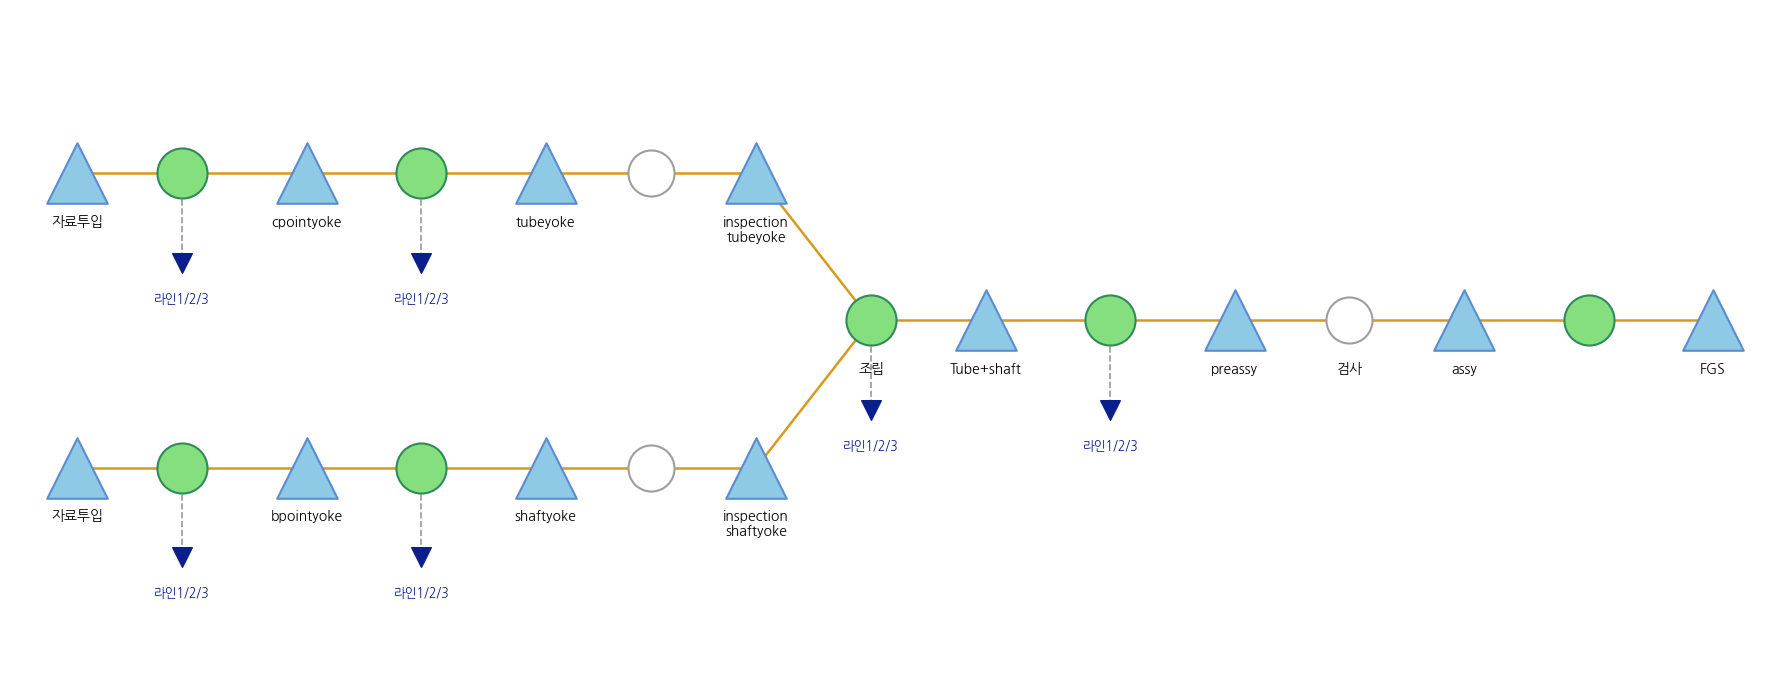


NetworkX → PyTorch Geometric 변환 중...

[PyTorch Geometric Data Object]
Data(x=[22, 3], edge_index=[2, 21], label=[22], type=[22])

노드 수: 22  |  엣지 수: 21

Node Features (x)  — [is_operation, is_buffer, is_inspection]:
  F_IN_TOP           [1.0, 0.0, 0.0]
  BUF_TOP_1          [0.0, 1.0, 0.0]
  OP20_TOP           [1.0, 0.0, 0.0]
  BUF_TOP_2          [0.0, 1.0, 0.0]
  OP30_TOP           [1.0, 0.0, 0.0]
  INSP_TOP           [0.0, 0.0, 1.0]
  OP40_TOP           [1.0, 0.0, 0.0]
  F_IN_BOTTOM        [1.0, 0.0, 0.0]
  BUF_BOT_1          [0.0, 1.0, 0.0]
  OP20_BOTTOM        [1.0, 0.0, 0.0]
  BUF_BOT_2          [0.0, 1.0, 0.0]
  OP30_BOTTOM        [1.0, 0.0, 0.0]
  INSP_BOTTOM        [0.0, 0.0, 1.0]
  OP40_BOTTOM        [1.0, 0.0, 0.0]
  ASSEMBLY           [0.0, 1.0, 0.0]
  OP50               [1.0, 0.0, 0.0]
  BUF_50_60          [0.0, 1.0, 0.0]
  OP60               [1.0, 0.0, 0.0]
  INSP_MAIN          [0.0, 0.0, 1.0]
  OP70               [1.0, 0.0, 0.0]
  POST70_BUF         [0.0, 1.0, 0.0]
  FGS 

In [7]:
import os
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import font_manager, rcParams
from matplotlib.font_manager import FontProperties
from torch_geometric.utils import from_networkx


# =========================================================
# 0. 상수 정의 (후속 연구에서 수정이 필요한 값들을 한 곳에 모음)
# =========================================================
NODE_SIZE = {
    "operation": 1900,
    "buffer": 1300,
    "inspection": 1100,
}
NODE_COLOR = {
    "operation":  ("#8ecae6", "#5b8bd0"),   # (fill, edge)
    "buffer":     ("#86df7f", "#2e8b57"),
    "inspection": ("white",   "#9e9e9e"),
}
LABEL_OFFSET_Y = -0.26   # 노드 라벨을 도형 아래로 내리는 오프셋
LINE_MARKER_COLOR = "#0b1f8a"
EDGE_COLOR_MAIN = "#d9991e"
EDGE_COLOR_AUX  = "#999999"


# =========================================================
# 1. 한글 폰트 설정
# =========================================================
def set_korean_font() -> FontProperties:
    # Install NanumGothic font if not already present in Colab
    if not os.path.exists("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"):
        print("[INFO] NanumGothic 폰트를 설치합니다...")
        os.system("apt-get update -qq")
        os.system("apt-get install fonts-nanum* -qq")
        # font_manager._rebuild() # This is an internal function and can cause AttributeError
        print("[INFO] 폰트 설치 완료. 런타임을 다시 시작해야 할 수도 있습니다.")

    candidates = [
        r"C:\Windows\Fonts\malgun.ttf",   # Windows
        "/System/Library/Fonts/AppleGothic.ttf",  # macOS
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",  # Linux (Colab default)
        # Add more paths if needed
    ]
    font_path = next((p for p in candidates if os.path.exists(p)), None)
    if font_path is None:
        raise FileNotFoundError("한글 폰트를 찾지 못했습니다. candidates 경로를 확인해주세요.")

    font_manager.fontManager.addfont(font_path)
    fp = FontProperties(fname=font_path)
    rcParams["font.family"] = fp.get_name()
    rcParams["axes.unicode_minus"] = False
    print(f"[INFO] 적용된 폰트: {fp.get_name()}")
    return fp


# =========================================================
# 2. 그래프 생성
#    ※ 시각용 라인마커는 그래프 노드에서 제거 → GNN 데이터 오염 방지
#    ※ 후속 연구: 노드 속성(spec)을 확장하려면 이 함수에서 추가
# =========================================================
def build_taerim_graph() -> nx.DiGraph:
    G = nx.DiGraph()

    # --- 노드 정의 {id: (label, type)} ---
    # type: "operation"(파란삼각형) / "buffer"(초록원) / "inspection"(흰원)
    node_defs = {
        # 상단 라인
        "F_IN_TOP":      ("자료투입",             "operation"),
        "BUF_TOP_1":     ("",                     "buffer"),
        "OP20_TOP":      ("cpointyoke",            "operation"),
        "BUF_TOP_2":     ("",                     "buffer"),
        "OP30_TOP":      ("tubeyoke",              "operation"),
        "INSP_TOP":      ("",                     "inspection"),
        "OP40_TOP":      ("inspection\ntubeyoke",  "operation"),
        # 하단 라인
        "F_IN_BOTTOM":   ("자료투입",             "operation"),
        "BUF_BOT_1":     ("",                     "buffer"),
        "OP20_BOTTOM":   ("bpointyoke",            "operation"),
        "BUF_BOT_2":     ("",                     "buffer"),
        "OP30_BOTTOM":   ("shaftyoke",             "operation"),
        "INSP_BOTTOM":   ("",                     "inspection"),
        "OP40_BOTTOM":   ("inspection\nshaftyoke", "operation"),
        # 합류 이후
        "ASSEMBLY":      ("조립",                 "buffer"),
        "OP50":          ("Tube+shaft",            "operation"),
        "BUF_50_60":     ("",                     "buffer"),
        "OP60":          ("preassy",               "operation"),
        "INSP_MAIN":     ("검사",                  "inspection"),
        "OP70":          ("assy",                  "operation"),
        "POST70_BUF":    ("",                     "buffer"),
        "FGS":           ("FGS",                  "operation"),
    }

    for nid, (label, ntype) in node_defs.items():
        # GNN feature 벡터 x: [is_operation, is_buffer, is_inspection]
        # 후속 연구에서 CT, 작업방법 등을 추가하면 여기서 확장
        x = [
            1.0 if ntype == "operation"  else 0.0,
            1.0 if ntype == "buffer"     else 0.0,
            1.0 if ntype == "inspection" else 0.0,
        ]
        G.add_node(nid, label=label, type=ntype, x=x)

    # --- 엣지 정의 ---
    top_flow    = ["F_IN_TOP", "BUF_TOP_1", "OP20_TOP", "BUF_TOP_2",
                   "OP30_TOP", "INSP_TOP",  "OP40_TOP", "ASSEMBLY"]
    bottom_flow = ["F_IN_BOTTOM", "BUF_BOT_1", "OP20_BOTTOM", "BUF_BOT_2",
                   "OP30_BOTTOM", "INSP_BOTTOM", "OP40_BOTTOM", "ASSEMBLY"]
    merged_flow = ["ASSEMBLY", "OP50", "BUF_50_60", "OP60",
                   "INSP_MAIN", "OP70", "POST70_BUF", "FGS"]

    for flow in (top_flow, bottom_flow, merged_flow):
        for u, v in zip(flow, flow[1:]):
            G.add_edge(u, v)

    return G


# =========================================================
# 3. 좌표 배치
# =========================================================
def get_positions() -> dict:
    Y_TOP, Y_BOT, Y_MID = 2.0, 0.2, 1.1

    pos = {
        "F_IN_TOP":    (0.0,  Y_TOP),
        "BUF_TOP_1":   (1.1,  Y_TOP),
        "OP20_TOP":    (2.4,  Y_TOP),
        "BUF_TOP_2":   (3.6,  Y_TOP),
        "OP30_TOP":    (4.9,  Y_TOP),
        "INSP_TOP":    (6.0,  Y_TOP),
        "OP40_TOP":    (7.1,  Y_TOP),

        "F_IN_BOTTOM": (0.0,  Y_BOT),
        "BUF_BOT_1":   (1.1,  Y_BOT),
        "OP20_BOTTOM": (2.4,  Y_BOT),
        "BUF_BOT_2":   (3.6,  Y_BOT),
        "OP30_BOTTOM": (4.9,  Y_BOT),
        "INSP_BOTTOM": (6.0,  Y_BOT),
        "OP40_BOTTOM": (7.1,  Y_BOT),

        "ASSEMBLY":    (8.3,  Y_MID),
        "OP50":        (9.5,  Y_MID),
        "BUF_50_60":   (10.8, Y_MID),
        "OP60":        (12.1, Y_MID),
        "INSP_MAIN":   (13.3, Y_MID),
        "OP70":        (14.5, Y_MID),
        "POST70_BUF":  (15.8, Y_MID),
        "FGS":         (17.1, Y_MID),
    }
    return pos


# =========================================================
# 4. 노드 그리기
# =========================================================
def draw_nodes(G: nx.DiGraph, pos: dict):
    for ntype in ("operation", "buffer", "inspection"):
        nodelist = [n for n, d in G.nodes(data=True) if d["type"] == ntype]
        fill, edge = NODE_COLOR[ntype]
        shape = "^" if ntype == "operation" else "o"
        nx.draw_networkx_nodes(
            G, pos, nodelist=nodelist,
            node_shape=shape,
            node_color=fill,
            edgecolors=edge,
            linewidths=1.5,
            node_size=NODE_SIZE[ntype],
        )


# =========================================================
# 5. 엣지 그리기
# =========================================================
def draw_edges(G: nx.DiGraph, pos: dict):
    nx.draw_networkx_edges(
        G, pos,
        edgelist=list(G.edges()),
        edge_color=EDGE_COLOR_MAIN,
        arrows=False,
        width=1.8,
    )


# =========================================================
# 6. 라벨 + 라인마커 그리기
#    라인마커는 시각 전용이므로 ax에 직접 scatter/text로 그림
# =========================================================
def draw_labels_and_markers(G: nx.DiGraph, pos: dict, kfont: FontProperties):
    ax = plt.gca()

    # 노드 라벨
    for node, data in G.nodes(data=True):
        label = data.get("label", "")
        if not label:
            continue
        x, y = pos[node]
        ax.text(x, y + LABEL_OFFSET_Y, label,
                fontproperties=kfont, ha="center", va="top",
                fontsize=10, color="black")

    # 라인마커: 버퍼(초록원) 노드 아래에 ▼ + 텍스트
    buffer_nodes_with_marker = [
        "BUF_TOP_1", "BUF_TOP_2",
        "BUF_BOT_1", "BUF_BOT_2",
        "ASSEMBLY",  "BUF_50_60",
    ]
    for node in buffer_nodes_with_marker:
        x, y = pos[node]
        my = y - 0.55   # 마커 y 위치
        ax.plot(
            [x, x],
            [y, my],
            linestyle="dashed",
            color="#999999",
            linewidth=1.2,
            zorder=1
        )
        ax.scatter(x, my, marker="v", s=200,
                   color=LINE_MARKER_COLOR, zorder=5)
        ax.text(x, my - 0.18, "라인1/2/3",
                fontproperties=kfont, ha="center", va="top",
                fontsize=9, color=LINE_MARKER_COLOR)


# =========================================================
# 7. 시각화 통합
# =========================================================
def visualize_graph(G: nx.DiGraph, kfont: FontProperties):
    fig, ax = plt.subplots(figsize=(18, 7))
    pos = get_positions()

    draw_edges(G, pos)
    draw_nodes(G, pos)
    draw_labels_and_markers(G, pos, kfont)

    ax.axis("off")
    ax.set_xlim(-0.7, 17.8)
    ax.set_ylim(-1.1, 3.0)
    plt.tight_layout()
    plt.show()


# =========================================================
# 8. GNN 데이터 변환 및 요약 출력
# =========================================================
def convert_to_pyg(G: nx.DiGraph):
    pyg_data = from_networkx(G)
    print("\n[PyTorch Geometric Data Object]")
    print(pyg_data)
    print(f"\n노드 수: {G.number_of_nodes()}  |  엣지 수: {G.number_of_edges()}")
    print("\nNode Features (x)  — [is_operation, is_buffer, is_inspection]:")
    for nid, data in G.nodes(data=True):
        print(f"  {nid:<18} {data['x']}")
    print("\nEdge Index:")
    print(pyg_data.edge_index)
    return pyg_data


# =========================================================
# 9. 메인
# =========================================================
def main():
    kfont   = set_korean_font()
    G       = build_taerim_graph()

    print("그래프 시각화를 시작합니다...")
    visualize_graph(G, kfont)

    print("\nNetworkX → PyTorch Geometric 변환 중...")
    pyg_data = convert_to_pyg(G)
    return G, pyg_data


if __name__ == "__main__":
    main()
